## Topic 1: Introduction to LSTM Architecture & Core Concepts

### 1. Introduction

**What is LSTM Architecture?**  
LSTM (Long Short-Term Memory) is a type of Recurrent Neural Network (RNN) designed to solve the **vanishing gradient problem**—a major issue where RNNs lose information over long sequences. While RNNs maintain only **one type of memory** (short-term), LSTMs maintain **two types of memory** and allow them to interact.

**Why is it important?**  
LSTMs are used in real-life applications like:
- Sentiment analysis (understanding if a review is positive or negative)
- Machine translation
- Speech recognition
- Time series forecasting (stock prices, weather)

**Key distinction from RNN:**  
- **RNN:** One line (memory) passing through each cell.  
- **LSTM:** Complex architecture with two memories—**long-term memory** (cell state) and **short-term memory** (hidden state)—and **gates** that control information flow.

---

### 2. Detailed Explanation

#### A. Two Types of Memory in LSTM

| Memory Type | Technical Name | Role |
|-------------|----------------|------|
| Long-term memory | **Cell State** (\( C_t \)) | Carries important information across many time steps. Think of it as a "conveyor belt" that runs through the entire sequence. |
| Short-term memory | **Hidden State** (\( h_t \)) | The output at the current time step, passed to the next step. |

> **Analogy:** Imagine reading a book.  
> - *Long-term memory* = the main plot you remember throughout the story.  
> - *Short-term memory* = the sentence you just read, which helps you understand the next sentence.

#### B. What Each LSTM Cell Does

An LSTM cell receives **3 inputs** and produces **2 outputs**:

**Inputs:**
1. Previous cell state (\( C_{t-1} \)) – long-term memory from the past
2. Previous hidden state (\( h_{t-1} \)) – short-term memory from the past
3. Current input (\( x_t \)) – the new data at this time step

**Outputs:**
1. Current cell state (\( C_t \)) – updated long-term memory
2. Current hidden state (\( h_t \)) – output for this time step (sent forward)

**Two-step process inside the cell:**
1. **Update the cell state** (long-term memory):
   - Decide what to **forget** from old memory
   - Decide what **new information** to add
2. **Calculate the hidden state** (short-term memory) from the updated cell state

#### C. The Concept of "Gates"

Gates are like **filters** that control how much information passes through. Each gate uses a **sigmoid activation function** (outputs values between 0 and 1), acting like a percentage:
- **0** = let nothing through (completely forget/block)
- **1** = let everything through (keep/add all)

The three gates in LSTM:
1. **Forget Gate** – decides what to remove from long-term memory
2. **Input Gate** – decides what new information to add to long-term memory
3. **Output Gate** – decides what to output as the hidden state

---

### 3. Key Points

- LSTM maintains **two memories**: cell state (long-term) and hidden state (short-term).
- LSTM solves the **vanishing gradient problem** of RNNs by allowing information to flow unchanged across many steps.
- The cell state acts as a **conveyor belt**—information can be added or removed, but it doesn't get diluted.
- **Gates** use sigmoid functions to control how much of each piece of information passes through.
- An LSTM cell takes **3 inputs** and produces **2 outputs**.
- The architecture is complex *only* to set up communication between long-term and short-term memory.

---

### 4. Common Mistakes

| Mistake | Why it Happens | How to Avoid |
|---------|----------------|--------------|
| Confusing cell state and hidden state | Both are vectors; beginners mix their roles | Remember: *Cell state = long-term memory (the "conveyor belt"); Hidden state = short-term memory (the output)* |
| Thinking gates are physical "doors" | Gates are mathematical operations (sigmoid + multiplication) | Think of gates as **filters with percentages**—they let 0% to 100% of information through |
| Skipping RNN basics | LSTM builds on RNN concepts | Watch RNN videos first; understand the vanishing gradient problem |
| Trying to memorize the diagram | The architecture looks intimidating | Break it down: forget gate → input gate → output gate. Understand each separately |

---

### 5. Interview / Exam Questions

**Q1: What are the main differences between RNN and LSTM?**  
**A:**  
- RNN has **one memory** (hidden state) that gets overwritten each step, causing vanishing gradients.  
- LSTM has **two memories** (cell state and hidden state) and uses **gates** to control what is kept, forgotten, or output. This allows LSTM to preserve information over long sequences.

**Q2: Why do LSTMs solve the vanishing gradient problem?**  
**A:** The cell state (\( C_t \)) is updated through **addition** (not just multiplication). In RNNs, repeated multiplications cause gradients to shrink. In LSTMs, the cell state can carry information unchanged for many steps because the forget gate can keep it intact.

**Q3: What is a "gate" in LSTM and how does it work?**  
**A:** A gate is a neural network layer with a **sigmoid activation** that produces values between 0 and 1. It is multiplied element-wise with a vector, acting as a filter: 0 = block all, 1 = pass all, values in between = pass partially.

---

### 6. Revision Notes (Quick Recap)

- LSTM = improved RNN that handles **long sequences** well.
- Maintains **two vectors**: \( C_t \) (long-term memory) and \( h_t \) (short-term memory).
- **Three gates**: Forget, Input, Output.
- Gates = sigmoid layers acting as **filters** (0 to 1).
- Cell update = **forget old** + **add new**.
- Hidden state = **filtered version** of cell state.
- All vectors inside an LSTM cell have the **same dimension** (\( d \)), which is the number of units in the layer.

---

**That concludes Topic 1.**  



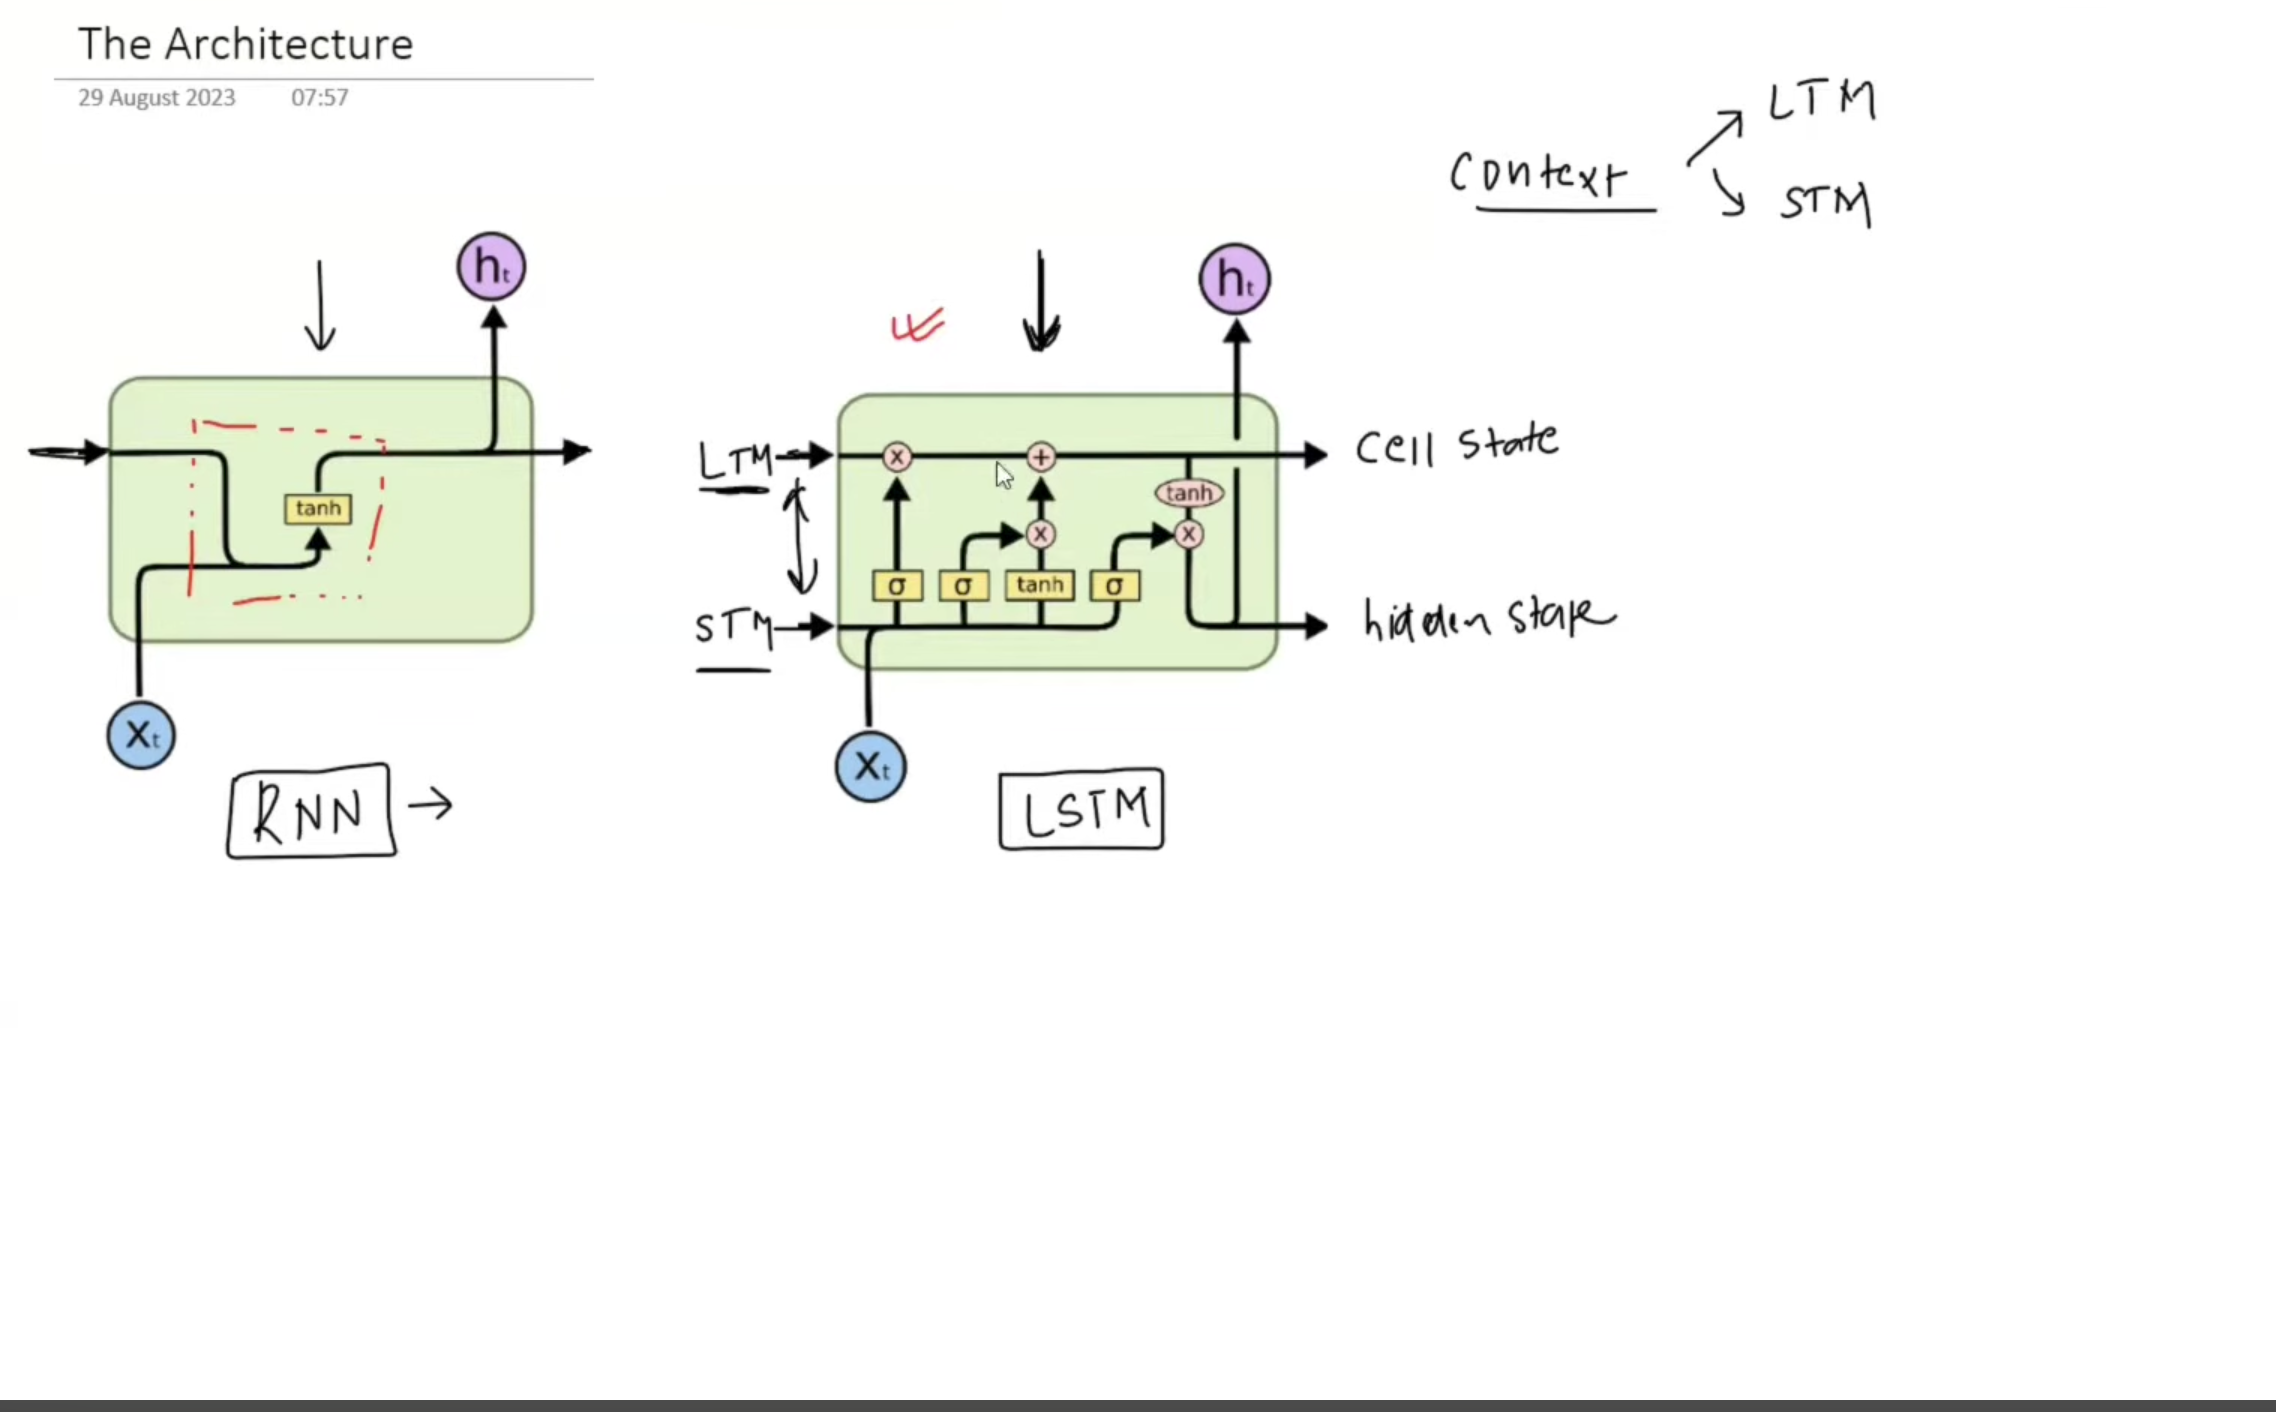
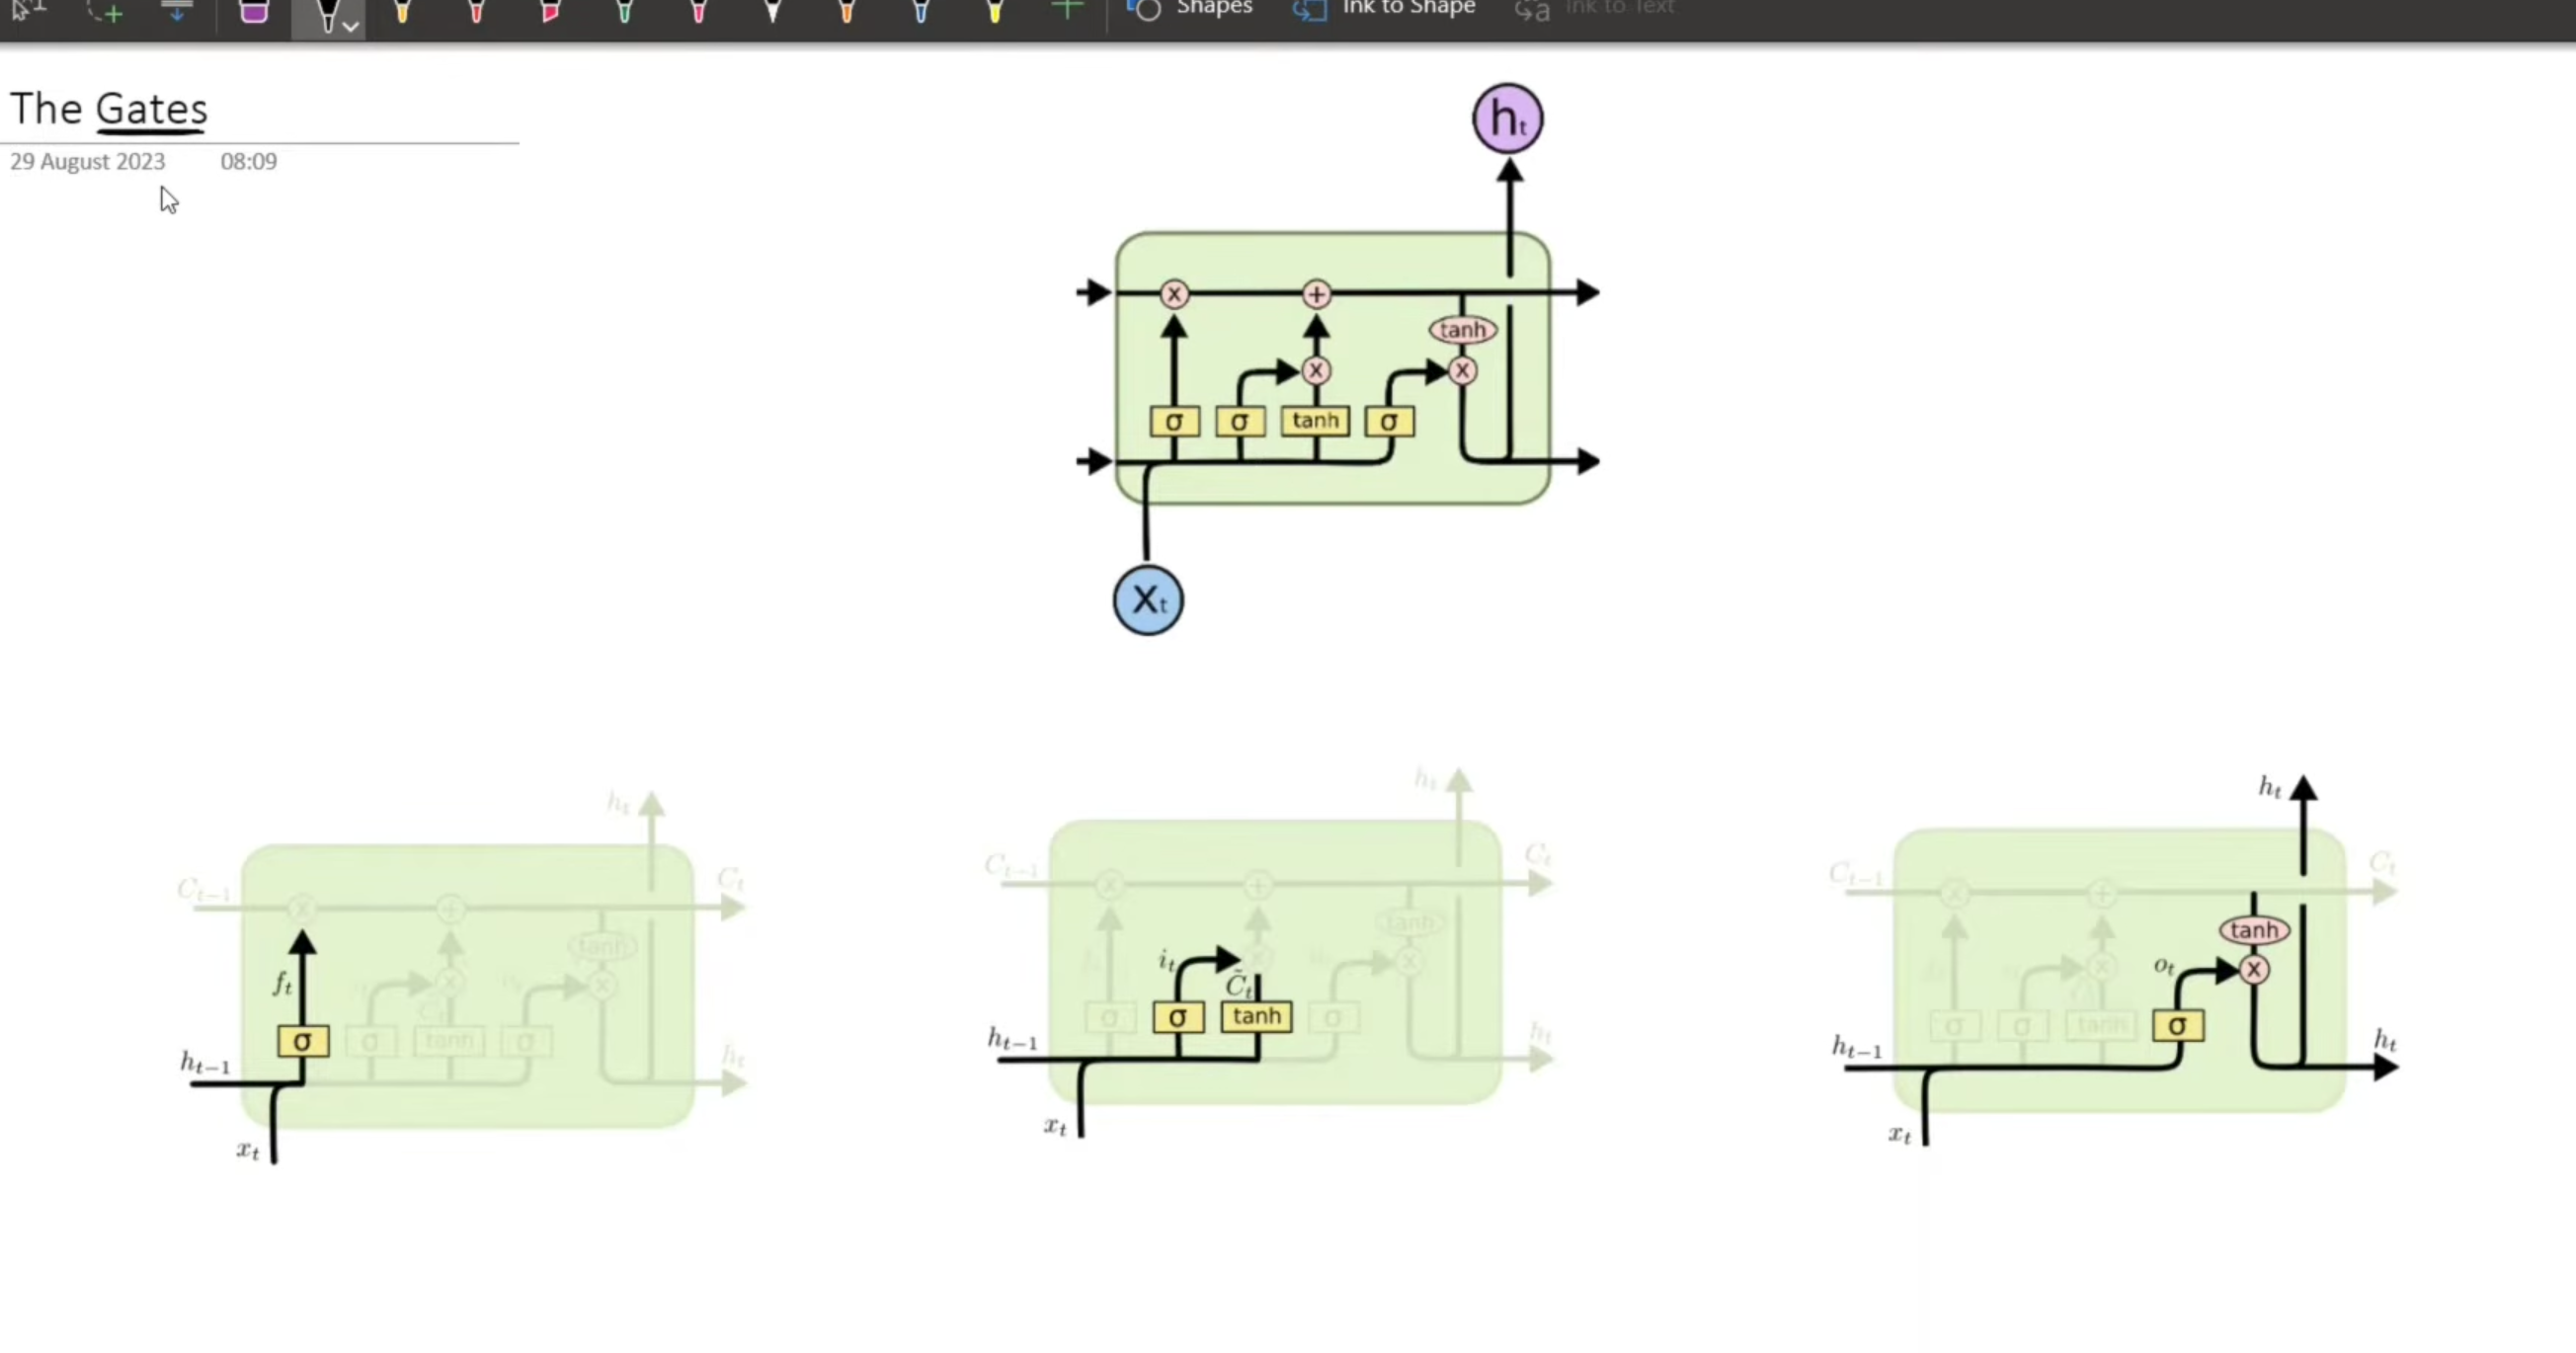

## Topic 2: The Forget Gate in Detail

### 1. Introduction

**What is the Forget Gate?**  
The forget gate is the **first gate** in an LSTM cell. Its job is to decide **what information to discard** from the long-term memory (cell state). Think of it as a "selective eraser" – it looks at the current input and the previous hidden state, then decides which parts of the old cell state are no longer relevant and should be removed.

**Why is it important?**  
Without a forget gate, the cell state would keep growing with irrelevant information, making the model less accurate. For example, in a story, when a king dies, you want to **forget** the old king's name and **remember** the new king's name. The forget gate enables this selective forgetting.

**Real-life analogy:**  
Imagine you have a whiteboard (cell state) with important notes. When new information arrives, you erase (forget) outdated notes before writing new ones. The forget gate decides *which notes to erase* and *how much* to erase.

---

### 2. Detailed Explanation

#### A. What the Forget Gate Receives (Inputs)

The forget gate receives **two inputs**:
1. **Previous hidden state** (\( h_{t-1} \)) – short-term memory from the past time step
2. **Current input** (\( x_t \)) – the new data at this time step

Both inputs are **concatenated** (joined together) into a single vector before processing.

#### B. Mathematical Representation

The forget gate is a **neural network layer** with:
- A **weight matrix** (\( W_f \))
- A **bias term** (\( b_f \))
- A **sigmoid activation function** (\( \sigma \))

**The equation:**

\[
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
\]

Where:
- \( f_t \) = forget gate output vector (values between 0 and 1)
- \( W_f \) = weight matrix for the forget gate
- \( [h_{t-1}, x_t] \) = concatenated input vector
- \( b_f \) = bias term
- \( \sigma \) = sigmoid function (squashes values to 0–1)

#### C. Step-by-Step Working

Let's break down what happens inside the forget gate:

| Step | Action | Explanation |
|------|--------|-------------|
| **1** | Concatenate \( h_{t-1} \) and \( x_t \) | Join the two input vectors into one larger vector |
| **2** | Multiply with weight matrix \( W_f \) | Linear transformation – each neuron connects to every input |
| **3** | Add bias \( b_f \) | Shift the result |
| **4** | Apply sigmoid activation | Convert each value to a number between 0 and 1 (the "percentage to keep") |
| **5** | Element-wise multiply with \( C_{t-1} \) | Decide how much of *each element* in the old cell state to keep |

#### D. How "Forgetting" Actually Works

The output \( f_t \) is a vector of values between 0 and 1. This vector is then **element-wise multiplied** with the previous cell state \( C_{t-1} \):

\[
\text{Result} = f_t \odot C_{t-1}
\]

Where \( \odot \) means **element-wise multiplication** (multiplying corresponding elements of two vectors).

**Example:**

Suppose \( C_{t-1} = [4, 5, 6] \) and \( f_t = [1, 0.5, 0] \)

| Element | Old Value | Gate Value | New Value | Meaning |
|---------|-----------|------------|-----------|---------|
| 1st | 4 | 1.0 | 4 × 1 = **4** | **Keep 100%** – fully retain |
| 2nd | 5 | 0.5 | 5 × 0.5 = **2.5** | **Keep 50%** – partially forget |
| 3rd | 6 | 0 | 6 × 0 = **0** | **Keep 0%** – completely forget |

> **Key insight:** The gate doesn't "delete" – it multiplies each value by a number between 0 and 1. The closer to 0, the more that piece of information is forgotten.

#### E. What is "Sigmoid"?

Sigmoid is an activation function that takes any real number and maps it to a value **between 0 and 1**.

\[
\sigma(x) = \frac{1}{1 + e^{-x}}
\]

- Very negative input → close to 0
- Very positive input → close to 1
- Zero input → 0.5

This makes it perfect for gates, because we want percentages (0 to 1).

---

### 3. Key Points

- The forget gate decides **what to remove** from long-term memory.
- It takes \( h_{t-1} \) and \( x_t \) as input, passes them through a **sigmoid layer**.
- Output \( f_t \) is a vector of values between **0 and 1**.
- \( f_t \) is multiplied **element-wise** with \( C_{t-1} \) to decide how much of each old memory element to keep.
- **1.0** = keep all; **0.0** = forget completely; **0.5** = keep half.
- The number of units in the forget gate determines the **dimension** of all vectors in the LSTM (\( d \)).

---

### 4. Syntax/Structure (Mathematical Form)

The forget gate can be represented as:

```
f_t = σ( W_f · [h_{t-1}, x_t] + b_f )
```

**Breaking it down line by line:**

| Part | Meaning |
|------|---------|
| \( f_t \) | Output vector of the forget gate (same dimension as cell state) |
| \( \sigma \) | Sigmoid activation – converts to 0–1 range |
| \( W_f \) | Weight matrix – learns which inputs are important |
| \( [h_{t-1}, x_t] \) | Concatenated vector – joins previous hidden state and current input |
| \( b_f \) | Bias – allows shifting the output |
| Result | A vector where each element is a "keep percentage" |

---

### 5. Code Example (Conceptual)

```python
import numpy as np

# Simulating forget gate computation

# Define dimensions
d = 3  # number of units (dimension of all vectors)

# Previous hidden state and current input (random values)
h_prev = np.array([0.2, 0.5, 0.1])          # shape: (3,)
x_t = np.array([0.8, 0.3, 0.6])             # shape: (3,)

# Concatenate: shape becomes (6,)
concat_input = np.concatenate([h_prev, x_t])

# Weight matrix for forget gate (randomly initialized)
# Shape: (d, 2*d) = (3, 6) because input is 6-dimensional
W_f = np.random.randn(3, 6)

# Bias (shape: 3,)
b_f = np.random.randn(3)

# Step 1: Linear transformation
linear_output = np.dot(W_f, concat_input) + b_f

# Step 2: Apply sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

f_t = sigmoid(linear_output)

print("Forget gate output (f_t):", f_t)

# Previous cell state
C_prev = np.array([4.0, 5.0, 6.0])

# Element-wise multiplication: decide what to keep
kept_memory = f_t * C_prev

print("\nOld cell state (C_prev):", C_prev)
print("Gate values (f_t):", f_t)
print("New remembered values (f_t * C_prev):", kept_memory)
```

**Output example:**
```
Forget gate output (f_t): [0.98 0.45 0.03]

Old cell state (C_prev): [4. 5. 6.]
Gate values (f_t): [0.98 0.45 0.03]
New remembered values: [3.92 2.25 0.18]
```

**Explanation:**
- First element (4): kept 98% → 3.92
- Second element (5): kept 45% → 2.25
- Third element (6): kept only 3% → 0.18 (almost completely forgotten)

---

### 6. Output (Step-by-Step Walkthrough)

| Step | Operation | Result Shape | Explanation |
|------|-----------|--------------|-------------|
| 1 | \( h_{t-1} \) | (3,) | Previous hidden state |
| 2 | \( x_t \) | (3,) | Current input |
| 3 | Concatenate → [\( h_{t-1}, x_t \)] | (6,) | Join them |
| 4 | Multiply by \( W_f \) (3×6) → Add \( b_f \) | (3,) | Linear layer |
| 5 | Apply sigmoid | (3,) | Values now 0–1 |
| 6 | Element-wise multiply with \( C_{t-1} \) | (3,) | Forgetting applied to each element of long-term memory |

---

### 7. Common Mistakes

| Mistake | Why It Happens | How to Avoid |
|---------|----------------|--------------|
| Thinking the gate "deletes" entire vectors | Confusing element-wise operation with vector deletion | Remember: it multiplies **each element** individually – some can be kept, some forgotten |
| Expecting outputs to be exactly 0 or 1 | Sigmoid gives continuous values | Gates are **probabilistic** – they keep *percentages*, not binary decisions |
| Confusing \( f_t \) with the final output | Similar naming conventions | \( f_t \) = forget gate output (internal); \( h_t \) = final hidden state (output to next cell) |
| Misunderstanding the dimension | Not tracking shapes | All vectors in LSTM (\( C_t, h_t, f_t, i_t, o_t \)) have the **same dimension** \( d \) |

---

### 8. Interview / Exam Questions

**Q1: What does the forget gate do in an LSTM?**  
**A:** The forget gate decides how much of the previous cell state to retain. It takes \( h_{t-1} \) and \( x_t \), passes them through a sigmoid layer to get values between 0 and 1, and multiplies those values element-wise with the previous cell state. Values near 1 keep information; values near 0 discard it.

**Q2: Why is the sigmoid function used in forget gates instead of tanh?**  
**A:** Sigmoid outputs values in the range (0,1), making it ideal for **gating** – it acts as a percentage or probability. Tanh outputs (-1,1) which is better for representing candidate values, not gates.

**Q3: What would happen if all forget gate outputs were always 1?**  
**A:** The cell state would never forget anything. Over long sequences, irrelevant information would accumulate, making the model less accurate and potentially causing exploding values.

**Q4: How does the forget gate help with vanishing gradients?**  
**A:** The forget gate can output values close to 1, allowing the cell state to pass through with little change. Since the information flows via **addition** (not repeated multiplication), gradients don't vanish over long sequences.

---

### 9. Revision Notes (Quick Recap)

- **Purpose:** Decide what to remove from long-term memory
- **Inputs:** \( h_{t-1} \) and \( x_t \)
- **Formula:** \( f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \)
- **Output:** A vector of values in [0, 1]
- **Action:** Multiply \( f_t \) with \( C_{t-1} \) (element-wise) → this is the "forgetting" step
- **Gate values:** 1 = keep all, 0 = forget all, values in between = partial keep
- **Key takeaway:** The forget gate is a **filter**, not a switch – it controls *how much* of each memory element to retain.

---

**That concludes Topic 2 – The Forget Gate.**  


## Topic 3: The Input Gate (Adding New Information)

### 1. Introduction

**What is the Input Gate?**  
The input gate is the **second gate** in an LSTM cell. Its job is to decide **what new information to add** to the long-term memory (cell state). While the forget gate removes outdated information, the input gate identifies valuable new information from the current input and previous hidden state, then selectively adds it to the cell state.

**Why is it important?**  
Without an input gate, the model couldn't learn new patterns from recent data. For example, in a story, when a new king is announced, the input gate decides to **add** the new king's name to long-term memory while the forget gate removes the old king's name.

**Real-life analogy:**  
Continuing the whiteboard analogy – after erasing outdated notes (forget gate), you write new important notes on the whiteboard. The input gate decides *what* to write and *how much* of it to write.

---

### 2. Detailed Explanation

#### A. Two-Step Process of the Input Gate

The input gate works in **two stages**:

| Stage | Component | Purpose |
|-------|-----------|---------|
| **Stage 1** | **Candidate Cell State** (\( \tilde{C}_t \)) | Create *potential* new values worth adding to memory |
| **Stage 2** | **Input Gate Filter** (\( i_t \)) | Decide *how much* of those candidate values to actually add |

> **Important:** The input gate produces **two separate vectors**: \( \tilde{C}_t \) (candidate values) and \( i_t \) (filter values). These are then multiplied together.

#### B. Stage 1: Candidate Cell State (\( \tilde{C}_t \))

This is a neural network layer that generates **candidate values** – suggestions for what could be added to long-term memory.

**The equation:**

\[
\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)
\]

Where:
- \( \tilde{C}_t \) = candidate cell state (potential new memory values)
- \( \tanh \) = hyperbolic tangent activation (outputs values between -1 and 1)
- \( W_c \) = weight matrix for the candidate layer
- \( [h_{t-1}, x_t] \) = concatenated previous hidden state and current input
- \( b_c \) = bias term

**Why use tanh instead of sigmoid?**  
- **Sigmoid** outputs 0 to 1 → good for gates (percentages)
- **Tanh** outputs -1 to 1 → good for candidate values (can be positive or negative contributions to memory)

#### C. Stage 2: Input Gate Filter (\( i_t \))

This is another neural network layer that decides **how much** of the candidate values to actually add. It acts as a filter.

**The equation:**

\[
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
\]

Where:
- \( i_t \) = input gate output (values between 0 and 1)
- \( \sigma \) = sigmoid activation (acts as a percentage filter)
- \( W_i \) = weight matrix for the input gate
- \( b_i \) = bias term

#### D. Combining Both Stages

The new information to add is:

\[
i_t \odot \tilde{C}_t
\]

**Element-wise multiplication** ensures that each element of the candidate vector is filtered independently.

**Example:**

| Element | Candidate Value (\( \tilde{C}_t \)) | Filter Value (\( i_t \)) | Added to Memory | Meaning |
|---------|-------------------------------------|--------------------------|-----------------|---------|
| 1st | 0.8 | 0.9 | 0.72 | Add 90% of this candidate |
| 2nd | -0.5 | 0.1 | -0.05 | Add only 10% (mostly ignore) |
| 3rd | 0.3 | 0.0 | 0.00 | Add nothing – completely ignore |

#### E. Final Cell State Update

The new cell state (\( C_t \)) is the **sum** of:
1. **Forgotten old memory** (\( f_t \odot C_{t-1} \)) – from forget gate
2. **New filtered information** (\( i_t \odot \tilde{C}_t \)) – from input gate

\[
C_t = (f_t \odot C_{t-1}) + (i_t \odot \tilde{C}_t)
\]

> **Key insight:** This is an **addition** operation, not multiplication. This is why LSTMs solve the vanishing gradient problem – the cell state is updated by adding, not repeatedly multiplying.

---

### 3. Key Points

- The input gate consists of **two separate neural network layers**:
  - **Candidate layer** (tanh activation) – generates potential new values
  - **Filter layer** (sigmoid activation) – decides how much to add
- **Formula for candidate:** \( \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \)
- **Formula for filter:** \( i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \)
- New memory added = \( i_t \odot \tilde{C}_t \)
- Final cell state = **forgotten old memory + filtered new memory**
- All vectors (\( C_t, h_t, \tilde{C}_t, i_t, f_t, o_t \)) have the **same dimension** \( d \)
- The **addition** operation is what prevents vanishing gradients

---

### 4. Syntax/Structure (Mathematical Form)

**Candidate cell state:**
```
C̃_t = tanh( W_c · [h_{t-1}, x_t] + b_c )
```

**Input gate filter:**
```
i_t = σ( W_i · [h_{t-1}, x_t] + b_i )
```

**Final cell state update:**
```
C_t = ( f_t ⊙ C_{t-1} ) + ( i_t ⊙ C̃_t )
```

**Breaking down the final update:**

| Part | Component | Purpose |
|------|-----------|---------|
| \( f_t \odot C_{t-1} \) | Forgetting | What we kept from old memory |
| \( i_t \odot \tilde{C}_t \) | Adding | What new information we add |
| \( + \) | Addition | Combines both – this is crucial for gradient flow |

---

### 5. Code Example

```python
import numpy as np

# Simulating input gate computation

d = 3  # dimension

# Previous hidden state and current input
h_prev = np.array([0.2, 0.5, 0.1])
x_t = np.array([0.8, 0.3, 0.6])

# Concatenate
concat_input = np.concatenate([h_prev, x_t])  # shape: (6,)

# ---- Stage 1: Candidate Cell State ----
W_c = np.random.randn(3, 6)  # weight matrix for candidate
b_c = np.random.randn(3)     # bias

def tanh(x):
    return np.tanh(x)

linear_c = np.dot(W_c, concat_input) + b_c
C_tilde = tanh(linear_c)  # values between -1 and 1

# ---- Stage 2: Input Gate Filter ----
W_i = np.random.randn(3, 6)  # weight matrix for input gate
b_i = np.random.randn(3)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

linear_i = np.dot(W_i, concat_input) + b_i
i_t = sigmoid(linear_i)  # values between 0 and 1

# ---- Combine: filtered new information ----
new_info_to_add = i_t * C_tilde

# ---- Forgetting from previous step (simulated) ----
# Assume forget gate output and previous cell state from Topic 2
f_t = np.array([0.98, 0.45, 0.03])  # from forget gate example
C_prev = np.array([4.0, 5.0, 6.0])  # old cell state

old_kept = f_t * C_prev

# ---- Final cell state update ----
C_t = old_kept + new_info_to_add

print("--- Input Gate Results ---")
print("Candidate values (C̃_t):", C_tilde)
print("Filter values (i_t):", i_t)
print("New info to add (i_t * C̃_t):", new_info_to_add)
print("\n--- Cell State Update ---")
print("Old kept after forgetting:", old_kept)
print("New info added:", new_info_to_add)
print("New cell state (C_t):", C_t)
```

**Explanation of output:**
- `C̃_t` = suggestions for new memory values (can be negative)
- `i_t` = how much of each suggestion to accept (0 to 1)
- `new_info_to_add` = filtered suggestions actually added
- `C_t` = old memory (after forgetting) + new memory

---

### 6. Output (Step-by-Step Walkthrough)

| Step | Operation | Shape | Explanation |
|------|-----------|-------|-------------|
| 1 | \( [h_{t-1}, x_t] \) | (6,) | Concatenate inputs |
| 2 | \( W_c \cdot [h_{t-1}, x_t] + b_c \) | (3,) | Linear transform for candidate |
| 3 | Apply tanh → \( \tilde{C}_t \) | (3,) | Candidate values (-1 to 1) |
| 4 | \( W_i \cdot [h_{t-1}, x_t] + b_i \) | (3,) | Linear transform for filter |
| 5 | Apply sigmoid → \( i_t \) | (3,) | Filter values (0 to 1) |
| 6 | \( i_t \odot \tilde{C}_t \) | (3,) | Filtered new information |
| 7 | \( f_t \odot C_{t-1} \) | (3,) | Old memory after forgetting |
| 8 | \( C_t = \text{Step 6} + \text{Step 7} \) | (3,) | Final updated cell state |

---

### 7. Common Mistakes

| Mistake | Why It Happens | How to Avoid |
|---------|----------------|--------------|
| Thinking the input gate is a single layer | The diagram shows two parallel paths | Remember: **two layers** – one for candidate values (tanh) and one for the filter (sigmoid) |
| Confusing \( \tilde{C}_t \) with \( C_t \) | Similar notation | \( \tilde{C}_t \) = **candidate** (potential); \( C_t \) = **actual** final cell state |
| Forgetting that candidate values can be negative | Tanh outputs -1 to 1 | Negative values *reduce* memory – this allows "subtracting" information |
| Thinking the input gate alone updates the cell state | Overlooking the forget gate | Cell state update = **forgotten old** + **filtered new** – both are needed |
| Expecting \( i_t \) to be binary (0 or 1) | Thinking of gates as switches | Sigmoid gives **continuous values** – it's a partial filter, not an on/off switch |

---

### 8. Interview / Exam Questions

**Q1: Why does the input gate have two separate neural network layers (tanh and sigmoid)?**  
**A:** The **tanh layer** generates candidate values (can be positive or negative contributions). The **sigmoid layer** acts as a filter, deciding how much of each candidate to actually add. Separating these allows the model to independently decide *what* to add and *how much* to add.

**Q2: What happens if \( i_t \) is all zeros?**  
**A:** No new information is added to the cell state. Only the forget gate's output determines the new cell state. The model ignores the current input completely for memory updates.

**Q3: Why is tanh used for the candidate cell state but sigmoid for the filter?**  
**A:** 
- **Tanh** outputs (-1, 1) – good for representing **values** (can increase or decrease memory)
- **Sigmoid** outputs (0, 1) – good for **percentages/gates** (how much to let through)

**Q4: How does the input gate help with long-term dependencies?**  
**A:** The input gate allows the model to **add** important new information to the cell state via addition (not multiplication). This means the signal doesn't decay over long sequences, helping preserve long-term dependencies.

**Q5: Write the complete cell state update equation.**  
**A:** 
\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]
Where \( f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \) and \( i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \) and \( \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \)

---

### 9. Revision Notes (Quick Recap)

**Input Gate Components:**
- **Candidate layer:** \( \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \)
- **Filter layer:** \( i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \)

**Purpose:** Add new, relevant information to long-term memory

**Key operations:**
- Candidate values = potential new memories
- Filter values = how much to accept (0 to 1)
- New info = \( i_t \odot \tilde{C}_t \)

**Final cell state update:**
\[
C_t = \underbrace{f_t \odot C_{t-1}}_{\text{what we keep from old}} + \underbrace{i_t \odot \tilde{C}_t}_{\text{what we add from new}}
\]

**Crucial takeaway:** The cell state is updated via **addition** – this is the secret to solving the vanishing gradient problem in RNNs.

---

**That concludes Topic 3 – The Input Gate.**  



## Topic 4: The Output Gate & Complete LSTM Cell Summary
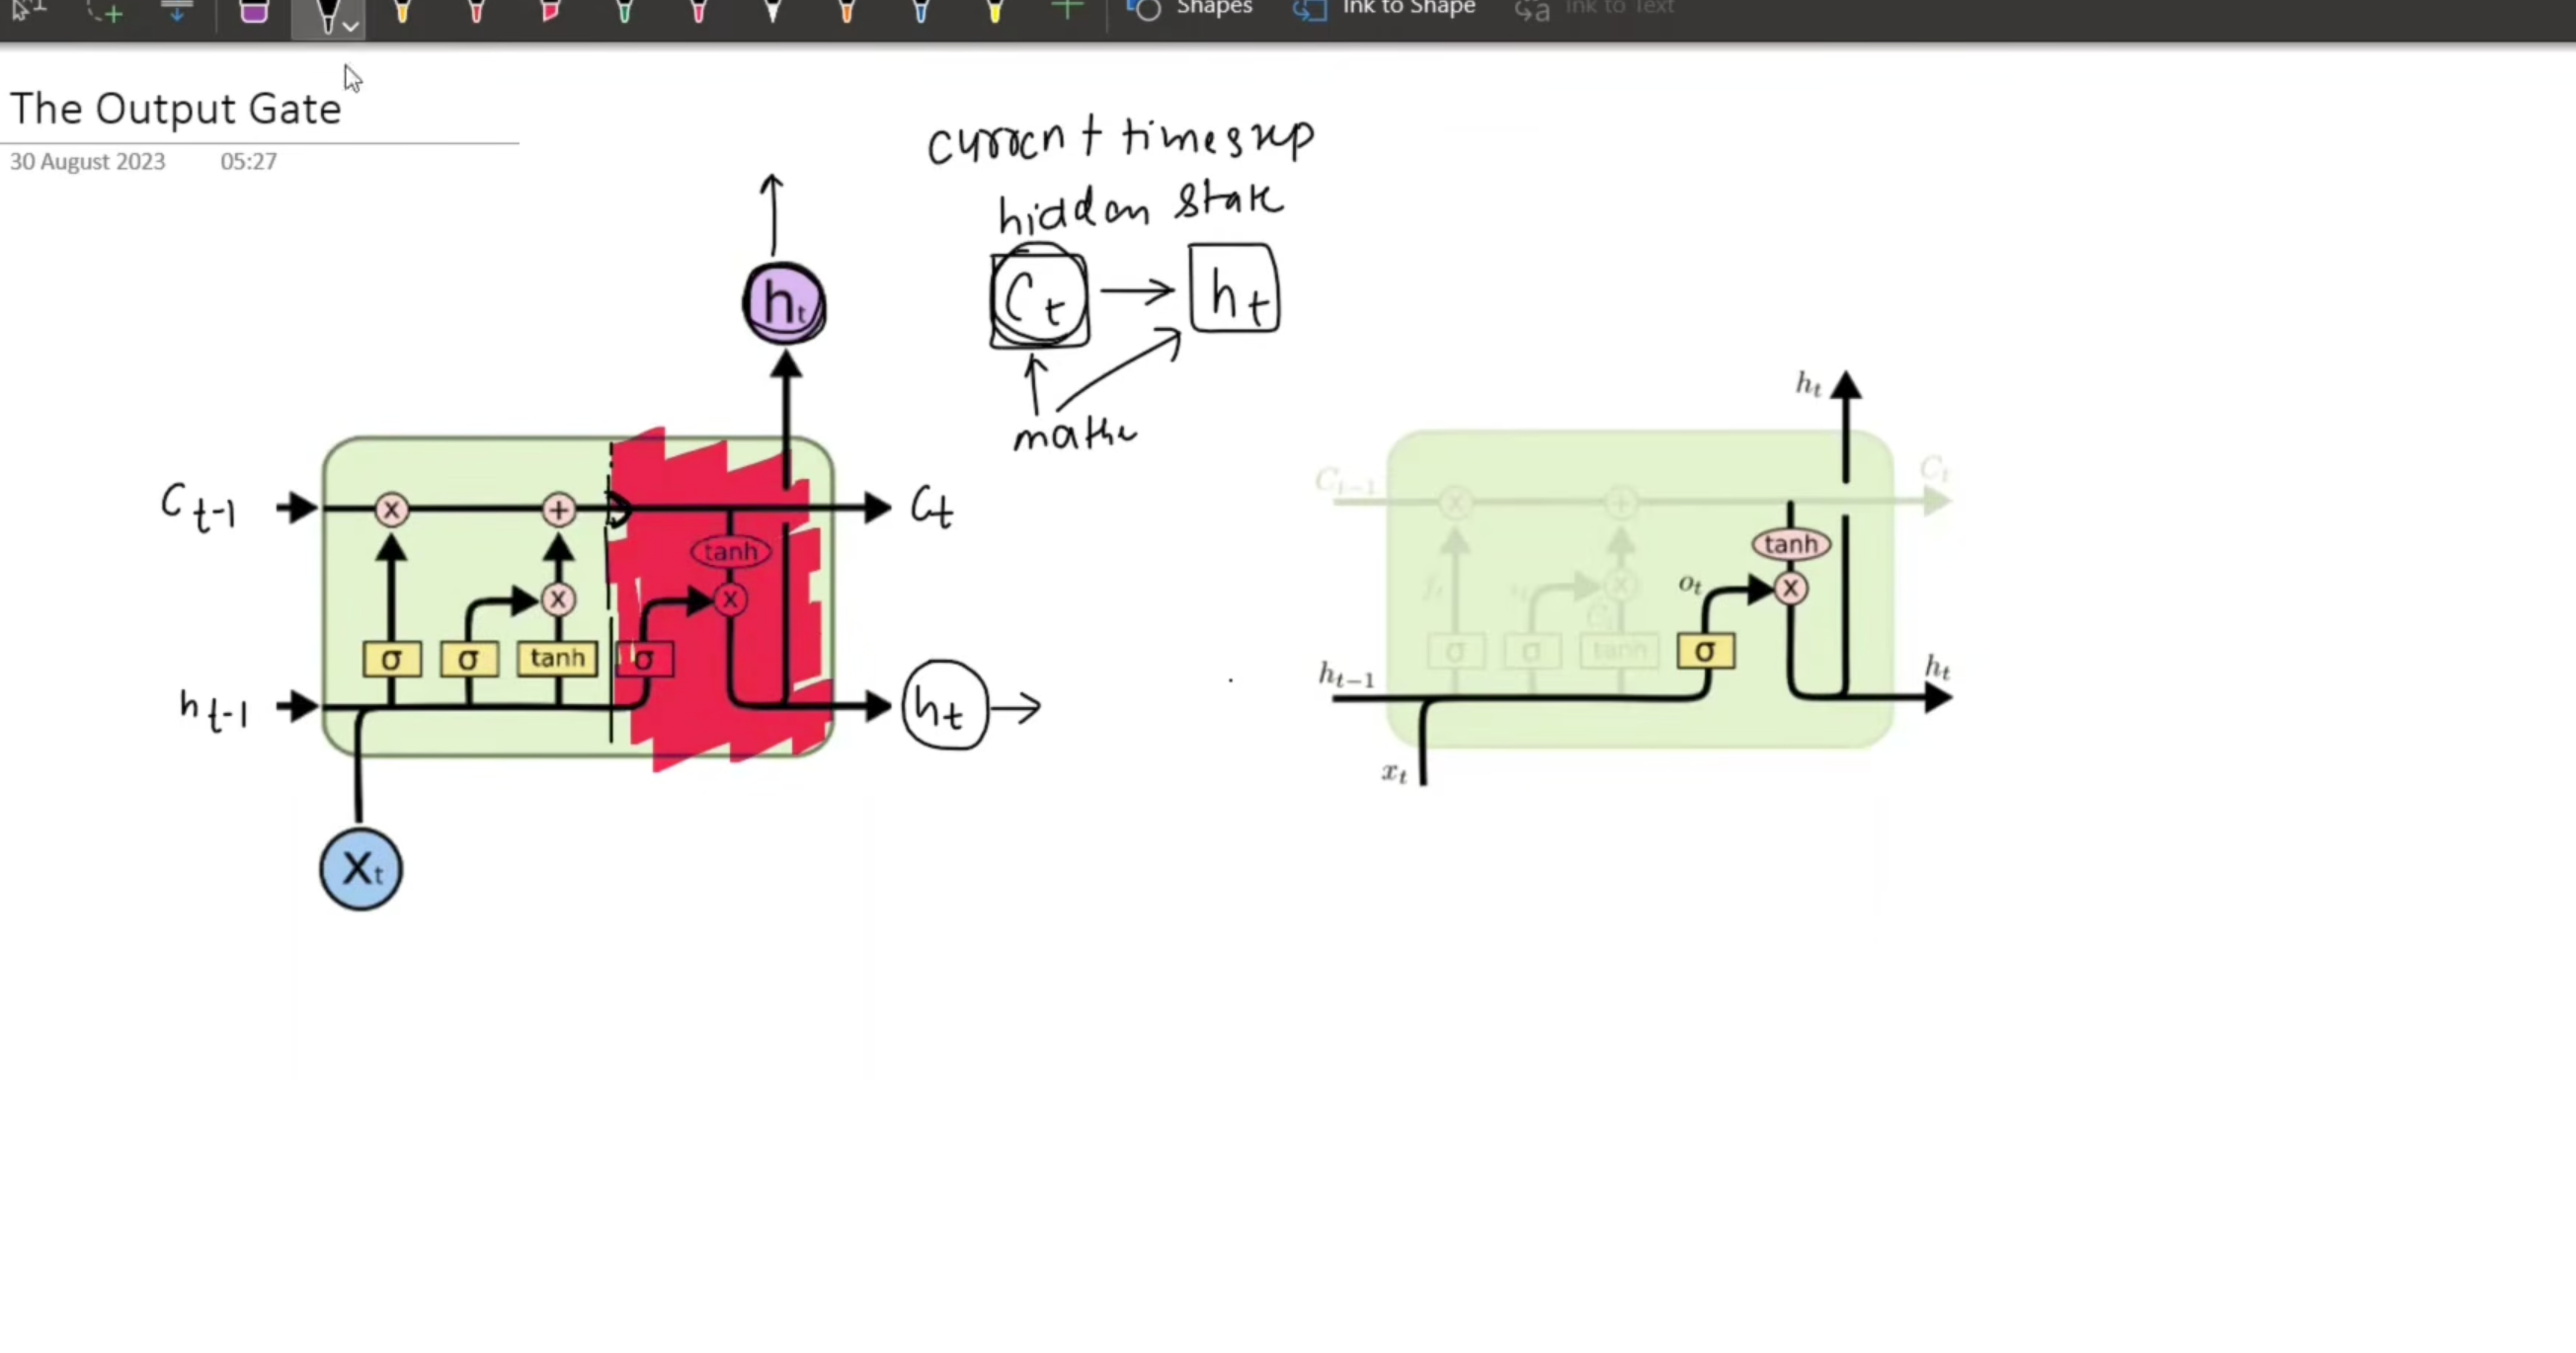
### 1. Introduction

**What is the Output Gate?**  
The output gate is the **third and final gate** in an LSTM cell. Its job is to decide **what the hidden state (short-term memory) will be** for the current time step. While the cell state is the long-term memory that flows through the entire sequence, the hidden state is the output that gets passed to the next cell and is used to make predictions at each step.

**Why is it important?**  
The hidden state (\( h_t \)) is what the LSTM actually outputs at each time step. It determines:
- What information is passed to the **next cell** in the sequence
- What is used for **prediction** at the current step (e.g., classifying a word's sentiment)

**Real-life analogy:**  
Continuing the whiteboard analogy – the whiteboard itself contains all your notes (cell state = long-term memory). But when someone asks you a question, you don't read the entire whiteboard aloud. Instead, you look at the whiteboard and decide which parts are relevant to the question, then summarize those in your answer. The output gate decides *which parts* of the whiteboard to share as your answer (\( h_t \)).

---

### 2. Detailed Explanation

#### A. What the Output Gate Does

The output gate takes the **current cell state** (\( C_t \)) and filters it to produce the **hidden state** (\( h_t \)).

**Two-step process:**

| Step | Operation | Purpose |
|------|-----------|---------|
| **1** | Calculate filter \( o_t \) using sigmoid | Decide *which elements* of the cell state to output |
| **2** | Apply tanh to \( C_t \), then multiply by \( o_t \) | Squash cell state values to (-1, 1), then filter |

> **Key insight:** The hidden state is **not** the cell state itself. It's a **filtered version** of the cell state, controlled by the output gate.

#### B. Step 1: Output Gate Filter (\( o_t \))

This is a neural network layer that decides **how much** of each element in the cell state should be output.

**The equation:**

\[
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
\]

Where:
- \( o_t \) = output gate values (between 0 and 1)
- \( \sigma \) = sigmoid activation (acts as a percentage filter)
- \( W_o \) = weight matrix for the output gate
- \( [h_{t-1}, x_t] \) = concatenated previous hidden state and current input
- \( b_o \) = bias term

#### C. Step 2: Calculating the Hidden State (\( h_t \))

First, the cell state is passed through a **tanh activation** to squash values between -1 and 1. Then, it is multiplied element-wise with the output gate filter.

**The equation:**

\[
h_t = o_t \odot \tanh(C_t)
\]

Where:
- \( h_t \) = current hidden state (output for this time step)
- \( o_t \) = output gate filter (0 to 1)
- \( \tanh(C_t) \) = cell state squashed to (-1, 1)

**Why apply tanh to \( C_t \) before outputting?**  
- The cell state can have arbitrary values (both positive and negative, possibly large)
- Tanh normalizes values to the range (-1, 1), making them stable and well-behaved for the next layer
- This is consistent with how hidden states are represented in LSTMs

#### D. Example of Output Gate Filtering

Suppose:
- \( C_t = [10, -5, 3] \) (current cell state)
- \( o_t = [0.9, 0.2, 0.7] \) (output gate filter)

**Step-by-step:**

| Element | \( C_t \) | Tanh(\( C_t \)) | \( o_t \) | Result (\( h_t \)) | Meaning |
|---------|-----------|----------------|-----------|-------------------|---------|
| 1st | 10 | ~1.0 | 0.9 | **0.9** | Output 90% of this strong positive signal |
| 2nd | -5 | ~-1.0 | 0.2 | **-0.2** | Output only 20% of this negative signal |
| 3rd | 3 | ~0.995 | 0.7 | **0.697** | Output 70% of this moderate signal |

---

### 3. Complete LSTM Cell – All Gates Together

Now that we've studied all three gates, let's put everything together.

#### The Complete LSTM Cell Equations

| Step | Component | Formula |
|------|-----------|---------|
| 1 | **Forget Gate** | \( f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \) |
| 2 | **Input Gate (Candidate)** | \( \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \) |
| 3 | **Input Gate (Filter)** | \( i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \) |
| 4 | **Cell State Update** | \( C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \) |
| 5 | **Output Gate (Filter)** | \( o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \) |
| 6 | **Hidden State Output** | \( h_t = o_t \odot \tanh(C_t) \) |

#### Visual Flow Summary

```
Inputs:  h_{t-1}, C_{t-1}, x_t
    │
    ├──► Forget Gate ──────────────────────► f_t
    │
    ├──► Candidate Layer ──────────────────► C̃_t
    │
    ├──► Input Gate ───────────────────────► i_t
    │
    ├──► C_t = (f_t ⊙ C_{t-1}) + (i_t ⊙ C̃_t)   ◄── Cell state updated
    │
    ├──► Output Gate ──────────────────────► o_t
    │
    └──► h_t = o_t ⊙ tanh(C_t)                 ◄── Hidden state output

Outputs: C_t, h_t
```

#### Why the "Addition" Operation is Crucial

**Problem in RNNs:** Hidden state is updated by repeated multiplication, causing gradients to vanish over long sequences.

\[
h_t = \sigma(W \cdot h_{t-1} + U \cdot x_t) \quad \text{(RNN – repeated multiplication)}
\]

**Solution in LSTMs:** Cell state is updated by **addition**, not multiplication.

\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(LSTM – addition)}
\]

The addition allows gradients to flow unchanged through the cell state, preserving information across hundreds of steps.

---

### 4. Key Points

- The output gate decides **what to output** as the hidden state (\( h_t \))
- Formula: \( o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \)
- Hidden state: \( h_t = o_t \odot \tanh(C_t) \)
- Tanh on \( C_t \) normalizes values to (-1, 1) before filtering
- **All gates use sigmoid** (for filtering); **candidate and output use tanh** (for value representation)
- All vectors have the same dimension \( d \) (number of units)
- The LSTM cell produces **two outputs**: \( C_t \) (to next cell) and \( h_t \) (to next cell and for prediction)

---

### 5. Syntax/Structure (Complete LSTM Cell)

```
# Input: h_{t-1}, C_{t-1}, x_t
# Output: h_t, C_t

# 1. Forget gate
f_t = sigmoid( W_f · [h_{t-1}, x_t] + b_f )

# 2. Candidate cell state
C̃_t = tanh( W_c · [h_{t-1}, x_t] + b_c )

# 3. Input gate
i_t = sigmoid( W_i · [h_{t-1}, x_t] + b_i )

# 4. Update cell state
C_t = ( f_t ⊙ C_{t-1} ) + ( i_t ⊙ C̃_t )

# 5. Output gate
o_t = sigmoid( W_o · [h_{t-1}, x_t] + b_o )

# 6. Compute hidden state
h_t = o_t ⊙ tanh( C_t )
```

---

### 6. Code Example (Complete LSTM Cell)

```python
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def lstm_cell(h_prev, C_prev, x_t, W_f, W_i, W_c, W_o, b_f, b_i, b_c, b_o):
    """
    Single LSTM cell forward pass.
    
    Args:
        h_prev: previous hidden state (shape: d)
        C_prev: previous cell state (shape: d)
        x_t: current input (shape: d)
        W_f, W_i, W_c, W_o: weight matrices (shape: d x 2d)
        b_f, b_i, b_c, b_o: bias vectors (shape: d)
    
    Returns:
        h_t: current hidden state
        C_t: current cell state
    """
    
    # Concatenate inputs
    concat = np.concatenate([h_prev, x_t])  # shape: (2d,)
    
    # 1. Forget gate
    f_t = sigmoid(np.dot(W_f, concat) + b_f)
    
    # 2. Candidate cell state
    C_tilde = tanh(np.dot(W_c, concat) + b_c)
    
    # 3. Input gate
    i_t = sigmoid(np.dot(W_i, concat) + b_i)
    
    # 4. Update cell state
    C_t = f_t * C_prev + i_t * C_tilde
    
    # 5. Output gate
    o_t = sigmoid(np.dot(W_o, concat) + b_o)
    
    # 6. Compute hidden state
    h_t = o_t * tanh(C_t)
    
    return h_t, C_t

# ---- Example usage ----
d = 3  # dimension
h_prev = np.array([0.1, 0.2, 0.3])
C_prev = np.array([1.0, 2.0, 3.0])
x_t = np.array([0.5, 0.6, 0.7])

# Randomly initialize weights (in practice, these are learned)
np.random.seed(42)
W_f = np.random.randn(d, 2*d) * 0.1
W_i = np.random.randn(d, 2*d) * 0.1
W_c = np.random.randn(d, 2*d) * 0.1
W_o = np.random.randn(d, 2*d) * 0.1
b_f = np.zeros(d)
b_i = np.zeros(d)
b_c = np.zeros(d)
b_o = np.zeros(d)

h_t, C_t = lstm_cell(h_prev, C_prev, x_t, W_f, W_i, W_c, W_o, b_f, b_i, b_c, b_o)

print("--- Complete LSTM Cell Output ---")
print("Inputs:")
print(f"  h_prev: {h_prev}")
print(f"  C_prev: {C_prev}")
print(f"  x_t:    {x_t}")
print("\nOutputs:")
print(f"  h_t (hidden state): {np.round(h_t, 3)}")
print(f"  C_t (cell state):  {np.round(C_t, 3)}")
```

---

### 7. Common Mistakes

| Mistake | Why It Happens | How to Avoid |
|---------|----------------|--------------|
| Thinking \( h_t \) is the same as \( C_t \) | Both are memories; names sound similar | \( C_t \) = long-term (passes through sequence); \( h_t \) = short-term (output for prediction) |
| Forgetting to apply tanh to \( C_t \) before output | Overlooking the equation | Always do: \( h_t = o_t \odot \tanh(C_t) \), not \( o_t \odot C_t \) |
| Confusing output gate \( o_t \) with output of the cell | Same prefix "output" | \( o_t \) is the **filter**; \( h_t \) is the **actual output** |
| Mixing up the order of operations | Many steps in the cell | Remember the order: Forget → Candidate → Input Filter → Update → Output Filter → Hidden State |
| Thinking all gates share weights | All gates look similar in diagrams | Each gate has **its own weight matrix** (\( W_f, W_i, W_c, W_o \)) – they are learned independently |

---

### 8. Interview / Exam Questions

**Q1: What is the purpose of the output gate in an LSTM?**  
**A:** The output gate controls what information from the cell state is exposed as the hidden state. It computes a filter (\( o_t \)) using sigmoid, applies tanh to the cell state to normalize it, then multiplies them to produce the hidden state (\( h_t = o_t \odot \tanh(C_t) \)).

**Q2: Why do we apply tanh to the cell state before outputting it?**  
**A:** The cell state can have values ranging from very negative to very positive. Tanh squashes these values to the range (-1, 1), making the hidden state stable and well-scaled for subsequent layers. It also matches the typical range of hidden states in neural networks.

**Q3: Write all four LSTM equations.**  
**A:** 
\[
\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \\
\tilde{C}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(C_t)
\end{aligned}
\]

**Q4: How does the LSTM solve the vanishing gradient problem?**  
**A:** The cell state \( C_t \) is updated through **addition** (\( C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \)), not repeated multiplication. This allows gradients to flow unchanged through the cell state over many time steps, preventing them from vanishing.

**Q5: What are the inputs and outputs of an LSTM cell at each time step?**  
**A:**  
**Inputs:** Previous hidden state (\( h_{t-1} \)), previous cell state (\( C_{t-1} \)), current input (\( x_t \))  
**Outputs:** Current hidden state (\( h_t \)), current cell state (\( C_t \))

---

### 9. Revision Notes (Quick Recap)

**Output Gate:**
- Purpose: Compute the hidden state (short-term memory) for the current step
- Formula: \( o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \)
- Hidden state: \( h_t = o_t \odot \tanh(C_t) \)

**Complete LSTM Cell Summary:**

| Gate | Purpose | Activation | Formula |
|------|---------|------------|---------|
| Forget | What to remove | Sigmoid | \( f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \) |
| Candidate | What could be added | Tanh | \( \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \) |
| Input | How much to add | Sigmoid | \( i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \) |
| Output | How much to output | Sigmoid | \( o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \) |

**Final Equations:**
- \( C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \) (cell state update)
- \( h_t = o_t \odot \tanh(C_t) \) (hidden state output)

**Key Insight:** The LSTM uses **two memories** (long-term and short-term) connected by **three gates** (forget, input, output), all working together to learn long-term dependencies.

---

**That concludes Topic 4 – The Output Gate & Complete LSTM Cell Summary.**  

The entire LSTM architecture is now covered. You have learned:
1. What LSTMs are and why they're important (Topic 1)
2. The Forget Gate – removing information (Topic 2)
3. The Input Gate – adding information (Topic 3)
4. The Output Gate – producing the hidden state (Topic 4)
